# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   str    
 1   Genero              2488 non-null   str    
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   str    
 4   Dependents          2500 non-null   str    
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   str    
 7   Servico_Internet    2500 non-null   str    
 8   Servico_Seguranca   2500 non-null   str    
 9   Suporte_Tecnico     2500 non-null   str    
 10  StreamingTV         2500 non-null   str    
 11  Tipo_Contrato       2500 non-null   str    
 12  PaymentMethod       2500 non-null   str    
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   str    
dtypes: float64(2), in

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [8]:
df.isnull().values.any()

np.True_

In [6]:
df.isnull().sum()

customerID               0
Genero                  12
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1482
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal       325
Total_Pago               0
Churn                    5
dtype: int64

In [9]:
(df.isnull().sum() / len(df))*100

customerID             0.00
Genero                 0.48
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
PhoneService          59.28
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Pagamento_Mensal      13.00
Total_Pago             0.00
Churn                  0.20
dtype: float64

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [10]:
df[df["Genero"].isnull()]

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN
10,9763-GRSKD,NaN,0,Yes,Yes,13,Yes,dsl,Yes,No,No,Month-to-month,Mailed check,NaN,587.45,No
11,7469-LKBCI,NaN,0,No,No,16,Yes,No,No internet service,No internet service,No internet service,Two year,Credit card (automatic),NaN,326.80,No
12,8091-TTVAX,NaN,0,Yes,No,58,Yes,Fiber optic,No,No,Yes,One year,Credit card (automatic),NaN,5681.10,No
13,0280-XJGEX,NaN,0,No,No,49,Yes,Fiber optic,No,No,Yes,Month-to-month,Bank transfer (automatic),NaN,5036.30,Yes


In [11]:
#Excluindo os dados das colunas faltantes de Genero, pois tem uma quantidade muito pequena de faltantes
df.dropna(subset=["Genero"], inplace=True)

In [12]:
df["Genero"].isnull().sum()

np.int64(0)

In [33]:
#Excluindo os dados das colunas faltantes de Genero, pois tem uma quantidade muito pequena de faltantes
df.dropna(subset=["Churn"], inplace=True)

In [34]:
df["Churn"].isnull().sum()

np.int64(0)

In [38]:
#Como a quantidade de dados nulos da coluna PhoneService é muito alta, mais que a metade, preencher com yes que seria a maioria, poderia trazer uma distorção para a analise, então melhor remover totalmente a coluna
df["PhoneService"].value_counts(dropna=False)

PhoneService
NaN    1482
Yes     920
No       86
Name: count, dtype: int64

In [39]:
df.drop(columns=["PhoneService"], inplace=True)

In [7]:
#Remoção da coluna de id, por ser dados sensíveis
df.drop(columns=["customerID"], inplace=True)

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

In [13]:
df["Pagamento_Mensal"].mean()

np.float64(65.60756321839081)

In [14]:
df["Pagamento_Mensal"].median()

np.float64(71.45)

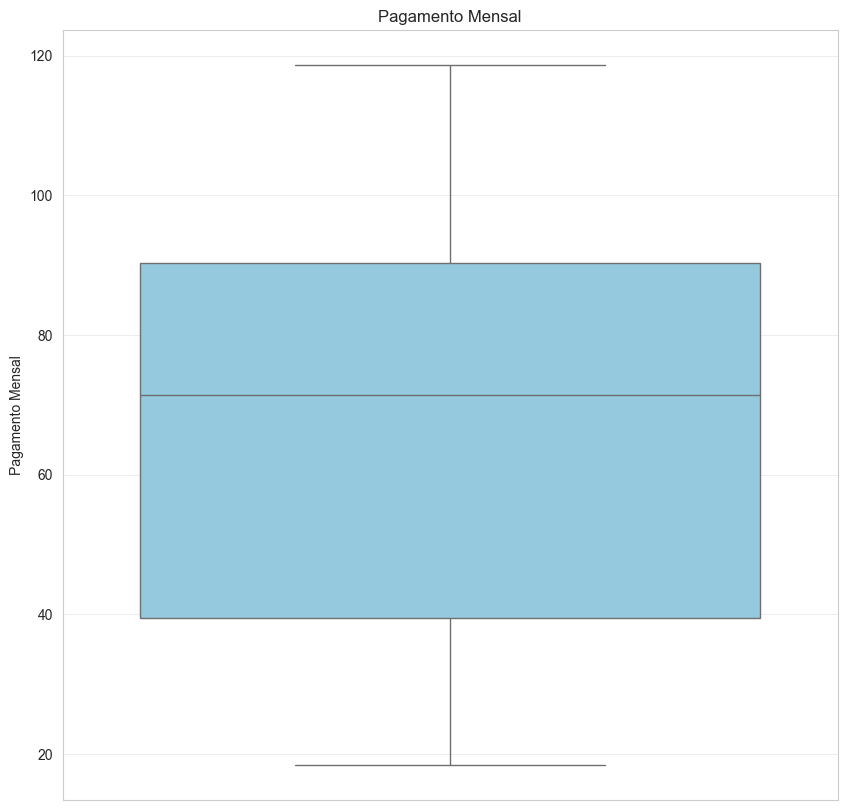

In [15]:
sns.set_style('whitegrid')

plt.figure(figsize=(10,10))
sns.boxplot(data=df, y="Pagamento_Mensal", color="skyblue")
plt.title("Pagamento Mensal")
plt.ylabel("Pagamento Mensal")
plt.show()


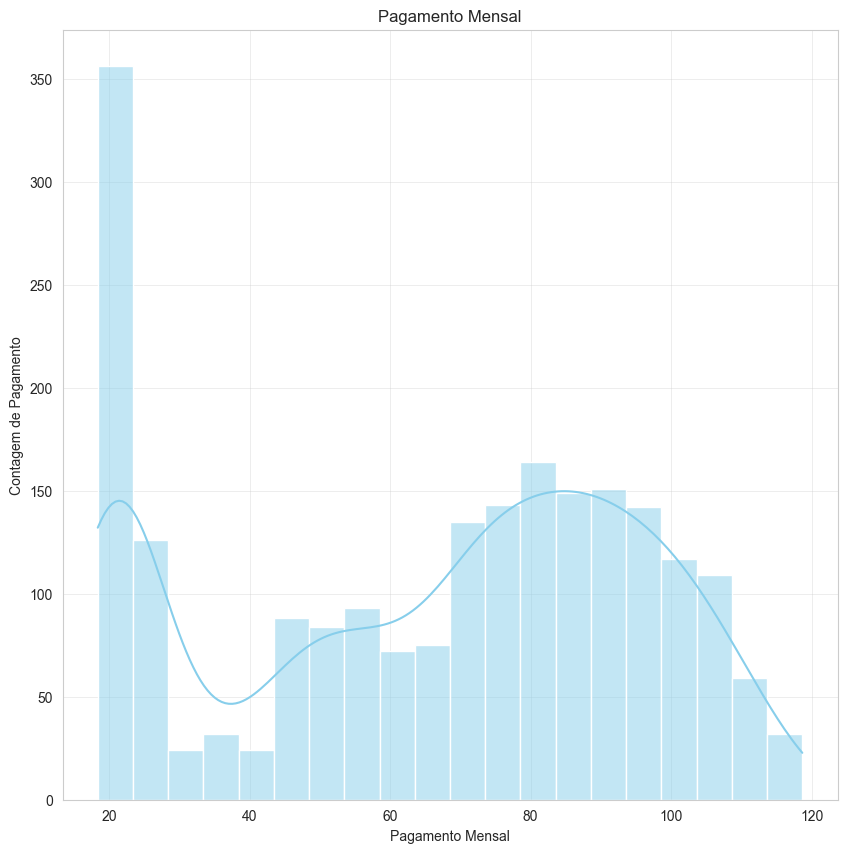

In [17]:
sns.set_style('whitegrid')

plt.figure(figsize=(10,10))
sns.histplot(data=df, x="Pagamento_Mensal",bins=20, kde=True, color="skyblue")
plt.title("Pagamento Mensal")
plt.xlabel("Pagamento Mensal")
plt.ylabel("Contagem de Pagamento")
plt.show()

A diferença entre a média e mediana esta em torno de 6, o que sugere que existem dados de pagamentos mensais puxando a média para baixo, e depois de analisar os gráfiso, acredito que a mediana é a melhor opção para esse caso.

In [27]:
mediana_pagamentos_mensais = df["Pagamento_Mensal"].median()

In [31]:
df["Pagamento_Mensal"] = df["Pagamento_Mensal"].fillna(mediana_pagamentos_mensais)

In [32]:
df["Pagamento_Mensal"].isnull().sum()

np.int64(0)

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [41]:
df.head(30)

df["Genero"].unique()

<StringArray>
['Female', 'Male', 'F', 'M', 'f']
Length: 5, dtype: str

In [43]:
df["Genero"] = df["Genero"].str.lower()
df["Genero"].unique()

<StringArray>
['female', 'male', 'f', 'm']
Length: 4, dtype: str

In [44]:
df["Genero"] = df["Genero"].replace("f", "female")
df["Genero"] = df["Genero"].replace("m", "male")
df["Genero"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [46]:
df["Servico_Internet"].unique()

<StringArray>
['DSL', 'No', 'Fiber optic', 'dsl']
Length: 4, dtype: str

In [47]:
df["Servico_Internet"] = df["Servico_Internet"].str.lower()
df["Servico_Internet"].unique()

<StringArray>
['dsl', 'no', 'fiber optic']
Length: 3, dtype: str

In [48]:
df["Servico_Seguranca"].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [49]:
df["Servico_Seguranca"] = df["Servico_Seguranca"].replace("No internet service", "No")
df["Servico_Seguranca"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [50]:
df["Suporte_Tecnico"].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [51]:
df["Suporte_Tecnico"] = df["Suporte_Tecnico"].replace("No internet service", "No")
df["Suporte_Tecnico"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [52]:
df["Tipo_Contrato"].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [53]:
df["PaymentMethod"].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [58]:
df.rename(columns={
    'Dependents': 'Dependentes',
    'PaymentMethod': 'Metodo_Pagamento',
    'MonthlyCharges': 'Pagamento_Mensal'
}, inplace=True)

df.info()

<class 'pandas.DataFrame'>
Index: 2488 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cliente_ID          2488 non-null   str    
 1   Genero              2488 non-null   str    
 2   Idoso               2488 non-null   int64  
 3   Casado              2488 non-null   str    
 4   Dependentes         2488 non-null   str    
 5   Tempo_como_Cliente  2488 non-null   int64  
 6   Servico_Internet    2488 non-null   str    
 7   Servico_Seguranca   2488 non-null   str    
 8   Suporte_Tecnico     2488 non-null   str    
 9   StreamingTV         2488 non-null   str    
 10  Tipo_Contrato       2488 non-null   str    
 11  Metodo_Pagamento    2488 non-null   str    
 12  Pagamento_Mensal    2488 non-null   float64
 13  Total_Pago          2488 non-null   float64
 14  Churn               2488 non-null   str    
dtypes: float64(2), int64(2), str(11)
memory usage: 311.0 KB
